### Libraries, data import & EDA

In [ ]:
!pip install sweetviz
!pip install sklearn
!pip install category_encoders


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# importing libraries
import numpy as np
import pandas as pd
from scipy.stats import boxcox

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import sweetviz as sv
from sklearn.cluster import KMeans
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [25]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [26]:
# quick eda with sweetviz
report = sv.analyze(adult)
report.show_html("sweetviz_report.html")

[Summarizing dataframe]                      |          | [  0%]   00:00 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Model agnostic data preprocessing & train/test split for reuse in all cells

In [27]:
# replace ? with np.nan
adult = adult.replace("?", np.nan)
adult.head()

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)  
    
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [28]:
# check for na values
adult.isna().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [29]:
# drop na values
adult = adult.dropna() # dropping nulls
adult.isna().sum() # checking for no nulls

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [30]:
# shuffle the data
adult = adult.sample(frac = 1, random_state = 42).reset_index(drop = True) # added a random seed to make consistent outputs
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,19,Self-emp-not-inc,30800,10th,6,Married-spouse-absent,Adm-clerical,Unmarried,Amer-Indian-Eskimo,0,0,0,40,United-States,0
1,45,Private,26781,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,Amer-Indian-Eskimo,1,0,0,40,United-States,0
2,47,Private,431515,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,1,0,0,40,United-States,1
3,23,Private,45713,Some-college,10,Never-married,Craft-repair,Other-relative,White,1,0,0,40,United-States,0
4,53,Local-gov,175897,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,1,0,0,40,United-States,0


In [31]:
# define features and target
X = adult.drop("income", axis=1)
y = adult["income"]

# define categorical and numerical columns from X
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# no ordinal columns anymore
ordinal_cols = []

# all categorical columns are now nominal
nominal_cols = cat_cols

print("Numerical:", num_cols)
print("Ordinal:", ordinal_cols)
print("Nominal:", nominal_cols)

# train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

C:\Users\prchandr\AppData\Local\Temp\1\ipykernel_14264\44353419.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


Numerical: ['age', 'fnlwgt', 'educational-num', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week']
Ordinal: []
Nominal: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']


# Data Processing Pipelines

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

education_order = [[
    'Preschool',
    '1st-4th',
    '5th-6th',
    '7th-8th',
    '9th',
    '10th',
    '11th',
    '12th',
    'HS-grad',
    'Some-college',
    'Assoc-voc',
    'Assoc-acdm',
    'Bachelors',
    'Masters',
    'Prof-school',
    'Doctorate'
]]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=education_order))
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('cat', nominal_pipeline, nominal_cols)
    ]
)

# applying preprocessors to my train/test split
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Constructing my neural networks

In [33]:
!pip install optuna
import optuna

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# get number of input features after preprocessing
input_shape = X_train_processed.shape[1]


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
def objective(trial):

    units1 = trial.suggest_categorical('units1', [32, 64, 128])
    units2 = trial.suggest_categorical('units2', [16, 32, 64])
    units3 = trial.suggest_categorical('units3', [0, 8, 16, 32])
    dropout_rate = trial.suggest_categorical('dropout_rate', [0.0, 0.1, 0.2])
    batch_size = trial.suggest_categorical('batch_size', [32, 64])

    model = keras.Sequential()
    model.add(keras.Input(shape=(input_shape,)))

    model.add(layers.Dense(units1, activation='relu'))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(units2, activation='relu'))

    if units3 > 0:
        model.add(layers.Dense(units3, activation='relu'))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_processed,
        y_train,
        validation_split=0.2,
        epochs=25,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    val_accuracy = max(history.history['val_accuracy'])

    print("Trial:", trial.number)
    print("Units:", units1, units2, units3)
    print("Dropout:", dropout_rate)
    print("Batch size:", batch_size)
    print("Val Accuracy:", val_accuracy)
    print("------------------------")

    return val_accuracy

In [35]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=5)

[I 2026-05-19 14:11:15,765] A new study created in memory with name: no-name-8c82367a-255e-493e-b5c5-ac517e06bdc9


[I 2026-05-19 14:12:07,783] Trial 0 finished with value: 0.8557214140892029 and parameters: {'units1': 64, 'units2': 16, 'units3': 0, 'dropout_rate': 0.0, 'batch_size': 64}. Best is trial 0 with value: 0.8557214140892029.


Trial: 0
Units: 64 16 0
Dropout: 0.0
Batch size: 64
Val Accuracy: 0.8557214140892029
------------------------


[I 2026-05-19 14:12:53,875] Trial 1 finished with value: 0.8571033477783203 and parameters: {'units1': 64, 'units2': 16, 'units3': 32, 'dropout_rate': 0.2, 'batch_size': 64}. Best is trial 1 with value: 0.8571033477783203.


Trial: 1
Units: 64 16 32
Dropout: 0.2
Batch size: 64
Val Accuracy: 0.8571033477783203
------------------------


...

Trial: 2
Units: 64 64 8
Dropout: 0.2
Batch size: 32
Val Accuracy: 0.856965184211731
------------------------


[I 2026-05-19 15:06:37,535] Trial 3 finished with value: 0.853233814239502 and parameters: {'units1': 32, 'units2': 32, 'units3': 16, 'dropout_rate': 0.0, 'batch_size': 64}. Best is trial 1 with value: 0.8571033477783203.


Trial: 3
Units: 32 32 16
Dropout: 0.0
Batch size: 64
Val Accuracy: 0.853233814239502
------------------------


[I 2026-05-19 15:07:40,507] Trial 4 finished with value: 0.8572415709495544 and parameters: {'units1': 128, 'units2': 32, 'units3': 0, 'dropout_rate': 0.1, 'batch_size': 64}. Best is trial 4 with value: 0.8572415709495544.


Trial: 4
Units: 128 32 0
Dropout: 0.1
Batch size: 64
Val Accuracy: 0.8572415709495544
------------------------


In [36]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(input_shape,))

x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(16, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="adult_income_neuralnet"
)

model.summary()

Model: "adult_income_neuralnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 103)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

In [38]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.8086 - auc: 0.8418 - loss: 0.4055 - precision: 0.6534 - recall: 0.4812 - val_accuracy: 0.8473 - val_auc: 0.9057 - val_loss: 0.3286 - val_precision: 0.7119 - val_recall: 0.6549
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8424 - auc: 0.8967 - loss: 0.3383 - precision: 0.7102 - recall: 0.6127 - val_accuracy: 0.8498 - val_auc: 0.9092 - val_loss: 0.3225 - val_precision: 0.7586 - val_recall: 0.5864
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8494 - auc: 0.9034 - loss: 0.3272 - precision: 0.7294 - recall: 0.6212 - val_accuracy: 0.8521 - val_auc: 0.9110 - val_loss: 0.3195 - val_precision: 0.7718 - val_recall: 0.5809
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8506 - auc: 0.9056 - loss: 0.3238 - precision: 0.7373 - recall: 0.6148 - val_accuracy: 0.8534 - val_auc: 0.9123 - val_loss: 0.3154 - val_precision: 0.7510 - val_recall: 0.6195
Epoch 5/20
453/453 ━━━━━━━

The first time I ran the model I recieved a val_accuracy: 0.8601 - val_loss: 0.3073. I used a three layered-feedforward model using neurons 64, 32, and 16 with a baseline of epochs = 20 and batch size = 64. I decided for the second model run (I restarted my kernal to see baseline performance for each model before deciding which model performed the best) to try feedforward strategy again but this time using neurons 16, 8, and 4 and epochs = 50 because the dataset was more structured and tabular, however it did not show improvement from the original model (val_accuracy: 0.8554 - val_loss: 0.3097). When I plotted it on the training and validation accuracy plot, I saw training accuracy was consistently higher than validation accuracy. Therefore the third time I re ran the model I tried with just two neural network layers with just 16 and 8, epochs = 50 and it still performed similar to the previous runs (val_accuracy: 0.8571 - val_loss: 0.3061).

Because I couldn't improve the model through layers or number of neurons I used the feedforward model that I tried originally (64, 32, 16 neurons, with epochs = 20) and training consistently performed better than validation, I used a dropout strategy with learning_rate = 0.001, new batch size of 32, and early stopping but this did not improve my model accuracy (val_accuracy: 0.8589 - val_loss: 0.3104)

# Training and Validation Accuracy

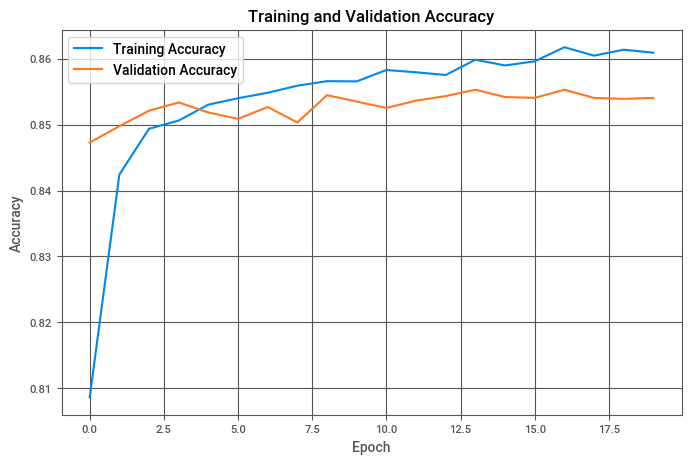

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()

In [40]:
scores = model.evaluate(
    X_test_processed,
    y_test,
    verbose=2
)

print("Test Accuracy:", scores[1])
print("Test Loss:", scores[0])

283/283 - 4s - 13ms/step - accuracy: 0.8502 - auc: 0.9088 - loss: 0.3169 - precision: 0.7311 - recall: 0.6258
Test Accuracy: 0.8501935005187988
Test Loss: 0.31686174869537354


# Evaluating metrics

In [41]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score
)

test_loss, test_accuracy, test_auc, test_precision, test_recall = model.evaluate(
    X_test_processed,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test AUC:", test_auc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

# predicted probabilities
y_prob = model.predict(X_test_processed).ravel()

# try multiple thresholds
thresholds = [0.3, 0.4, 0.5, 0.52, 0.6, 0.7]

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\nThreshold: {t}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")

# choose one threshold for detailed evaluation
y_pred = (y_prob >= 0.52).astype(int)

283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8502 - auc: 0.9088 - loss: 0.3169 - precision: 0.7311 - recall: 0.6258
Test Accuracy: 0.8501935005187988
Test AUC: 0.9087902307510376
Test Precision: 0.7311099767684937
Test Recall: 0.6257805824279785
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step

Threshold: 0.3
Accuracy: 0.8224
F1 Score: 0.6922

Threshold: 0.4
Accuracy: 0.8451
F1 Score: 0.6971

Threshold: 0.5
Accuracy: 0.8502
F1 Score: 0.6744

Threshold: 0.52
Accuracy: 0.8499
F1 Score: 0.6663

Threshold: 0.6
Accuracy: 0.8511
F1 Score: 0.6451

Threshold: 0.7
Accuracy: 0.8408
F1 Score: 0.5760


In [42]:

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_prob))


Confusion Matrix:
[[6331  472]
 [ 886 1356]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6803
           1       0.74      0.60      0.67      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.77      0.78      9045
weighted avg       0.84      0.85      0.84      9045


ROC AUC Score:
0.9087833554042839


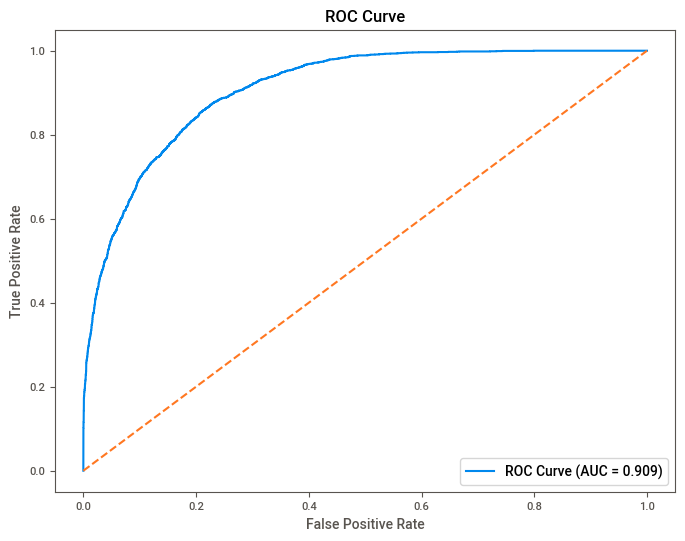

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# calculate AUC score
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

# Data Cleaning and Preprocessing
1. Determine whether missing values should be dropped, imputed, or flagged
2. scale numeric features and apply feature engineering when possible
3. try one hot encoding for baseline tabular models before trying other types of encoding
4. test embeddings if categorical dimensionality is large
# Baseline Architecture Strategy
1. start with a shallow dense feedforward strategy 
2. establish baseline performance using flat architecture to compare other architecture types to
3. avoid increasing layers unless validation accuracy does not improve or is decreasing
# Tuning the model
1. Use GridSearch or RandomizedCV
2. Use learning rate to account for the weights of connections between neurons and reduce how strongly features matter (goal: decrease validation loss) (default: 0.001 for baseline + 0.0005 for more stability + 0.0001 when the data is overfitting)
3. Tune drop out if the training and validation accuracy to clearly different. Dropout helps with decreasing overfitting which NNs struggle with (default: 0.1)
4. Batch sizes changes how many model sees before updating weights (smaller is better for generalizing the data) (default: 32)
5. Epochs should be tuned last based on an epoch and accuracy performance plot (validation/loss curve and early stopping)
# Evaluation
1. For NNs ROC AUC can be a strong metric for seeing how fast the model is learnig
2. Probability thresholds can be helpful if the classes are imbalanced (especially if it's affecting precision or recall)
3. Confusion Matrix is always helpful in seeing performance 
# Debugging
1. Avoid the model weight memorization of the previous model run by restarting kernal (and for a fair comparison between model performance)
2. Plot validation and training accuracy (goal: avoid overfitting to training test if data is smaller)
3. Use feature engineering to improve model performance if possible
4. Set a random seet to stabilize model outputs vary 